# Project 2 — LendingClub Credit Funnel
## Notebook 03: Modeling, Tuning, Evaluation & Business Impact

**Author:** Eric Bowers · **Framework:** CRISP-DM (Modeling + Evaluation stages)

**BLUF.** Using the leak-free pipeline from Notebook 02, this notebook trains and
tunes **three algorithms** (Logistic Regression, Random Forest, Gradient Boosting),
selects a winner by cross-validated ROC-AUC / PR-AUC, and evaluates it on a
**stratified holdout** and a **later-vintage (time-based) test set**. It then runs
the pitch's central experiment — the model **with vs. without** LendingClub's own
risk grades — tunes a decision threshold on business cost, checks calibration, and
translates the scores into a **lift/gains curve and an expected-loss / profit story**
framed as an approval-rate dial. Finally it fits the secondary
**policy-characterization** model (approved vs. declined) with a geographic
fairness read. The final tuned pipeline is serialized for reuse.

**Inputs:** `data/interim/accepted_terminal_whitelist.parquet`, `src/lc_transformers.py`,
and the raw `rejected_2007_to_2018q4.csv` (for the policy model only).
**Output:** `models/final_default_model.joblib` + a model card.

## 0 · Setup

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

sys.path.insert(0, "src")   # so the pickled pipeline's custom classes resolve
from lc_transformers import (CreditFeatureEngineer, RareCategoryGrouper, RiskMissingFlag,
                             LOG_COLS, MTHS_SINCE_COLS, INSTALLMENT_BLOCK, EMP_LENGTH_MAP)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             brier_score_loss, log_loss, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import sklearn; print("scikit-learn", sklearn.__version__)

scikit-learn 1.6.1


### 0.1 · Gradient-boosting library selection

Prefer **LightGBM**, then **XGBoost**, then scikit-learn's
**HistGradientBoostingClassifier** (always available, memory-efficient). Imbalance
is handled per-library (`scale_pos_weight` for the boosters, `class_weight` for HGB).

In [2]:
def make_gbm(y_train=None, random_state=RANDOM_STATE, **kw):
    """Return the best available gradient-boosting classifier with imbalance handling."""
    spw = None
    if y_train is not None:
        pos = float((y_train == 1).sum()); neg = float((y_train == 0).sum())
        spw = neg / max(pos, 1.0)
    try:
        from lightgbm import LGBMClassifier
        params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                      subsample=0.8, colsample_bytree=0.8, random_state=random_state,
                      n_jobs=-1, verbose=-1)
        if spw: params["scale_pos_weight"] = spw
        params.update(kw)
        return LGBMClassifier(**params), "LightGBM"
    except ImportError:
        pass
    try:
        from xgboost import XGBClassifier
        params = dict(n_estimators=400, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                      eval_metric="auc", random_state=random_state, n_jobs=-1)
        if spw: params["scale_pos_weight"] = spw
        params.update(kw)
        return XGBClassifier(**params), "XGBoost"
    except ImportError:
        pass
    params = dict(max_iter=400, learning_rate=0.05, max_depth=None,
                  class_weight="balanced", random_state=random_state)
    params.update(kw)
    return HistGradientBoostingClassifier(**params), "HistGradientBoosting"

_gbm, _name = make_gbm()
print("Gradient-boosting backend:", _name)

Gradient-boosting backend: HistGradientBoosting


### 0.2 · Configuration

To keep 1.35M-row training tractable in a notebook, the **model leaderboard** and
**hyperparameter search** run on stratified subsamples; the **winner is refit on
the full training set**. Business assumptions (loss-given-default, margin) are
explicit and easy to change.

In [3]:
INTERIM_DIR, MODEL_DIR = "data/interim", "models"
os.makedirs(MODEL_DIR, exist_ok=True)
PARQUET = os.path.join(INTERIM_DIR, "accepted_terminal_whitelist.parquet")
CSV_FALLBACK = PARQUET.replace(".parquet", ".csv")
REJECTED_CSV = "data/raw/rejected_2007_to_2018q4.csv"

INCLUDE_LC_RISK = False        # primary = independent model (exclude grade/int_rate)
LC_RISK_COLS = ["grade", "sub_grade", "int_rate", "int_rate_num"]

TEST_SIZE = 0.20
TIME_SPLIT_TRAIN_MAX_YEAR = 2016
MODEL_CMP_SAMPLE_N = 150_000   # rows for the 3-model leaderboard
TUNE_SAMPLE_N      = 150_000   # rows for randomized search
N_SEARCH_ITER      = 25

# --- Business assumptions (edit to the client's economics) -------------------
LGD    = 0.55   # loss given default: fraction of principal lost on a charge-off
MARGIN = 0.12   # net margin captured on a fully-repaid loan (fraction of principal)

## 1 · Load data, rebuild preprocessing, split

We reconstruct the exact feature-engineering + preprocessing block from the
module (not a pickle), so this notebook is self-contained, then apply the same
stratified and time-based splits as Notebook 02.

In [4]:
df = pd.read_parquet(PARQUET) if os.path.exists(PARQUET) else pd.read_csv(CSV_FALLBACK)
y = df["target"].astype("int8")
issue_dt = pd.to_datetime(df["issue_dt"]) if "issue_dt" in df.columns else pd.Series(pd.NaT, index=df.index)
X = df.drop(columns=[c for c in ["target", "issue_dt"] if c in df.columns])
if not INCLUDE_LC_RISK:
    X = X.drop(columns=[c for c in LC_RISK_COLS if c in X.columns])
print("X:", X.shape, "| default rate:", round(y.mean(), 4))

X: (1348099, 85) | default rate: 0.1998


In [5]:
def build_preprocess():
    num = Pipeline([("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler())])
    cat = Pipeline([("rare", RareCategoryGrouper(top_n=15)),
                    ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20))])
    return ColumnTransformer(
        [("num", num, make_column_selector(dtype_include=np.number)),
         ("cat", cat, make_column_selector(dtype_include=["object", "category"]))],
        remainder="drop")

def build_fe():
    return CreditFeatureEngineer(mths_cap=180, log_cols=LOG_COLS, mths_cols=MTHS_SINCE_COLS,
                                 installment_block=INSTALLMENT_BLOCK, emp_length_map=EMP_LENGTH_MAP)

def make_pipeline(clf):
    return Pipeline([("fe", build_fe()), ("prep", build_preprocess()), ("clf", clf)])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print(f"Stratified split — train {X_train.shape}, test {X_test.shape}")

# Later-vintage (time-based) split for a drift-aware test.
yr = pd.to_datetime(issue_dt).dt.year
tr_mask = (yr <= TIME_SPLIT_TRAIN_MAX_YEAR).values
te_mask = (yr > TIME_SPLIT_TRAIN_MAX_YEAR).values
Xtr_t, Xte_t, ytr_t, yte_t = X[tr_mask], X[te_mask], y[tr_mask], y[te_mask]
print(f"Time-based split — train<= {TIME_SPLIT_TRAIN_MAX_YEAR}: {tr_mask.sum():,} | "
      f"test 2017-18: {te_mask.sum():,}")

Stratified split — train (1078479, 85), test (269620, 85)
Time-based split — train<= 2016: 1,122,460 | test 2017-18: 225,639


## 2 · Model leaderboard — three algorithms, cross-validated

Each algorithm is dropped into the **same** pipeline (preprocessing re-fit inside
every fold, so no leakage). We compare on a stratified subsample for speed, using
ROC-AUC and PR-AUC (both robust to the ~20% imbalance).

In [7]:
# Stratified subsample for the leaderboard.
idx = (X_train.assign(_y=y_train.values)
       .groupby("_y", group_keys=False)
       .apply(lambda g: g.sample(min(len(g), MODEL_CMP_SAMPLE_N // 2),
                                 random_state=RANDOM_STATE)).index)
Xs, ys = X_train.loc[idx], y_train.loc[idx]
print("Leaderboard sample:", Xs.shape, "| default rate:", round(ys.mean(), 4))

gbm_est, gbm_name = make_gbm(ys)
candidates = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced",
                                 solver="saga", n_jobs=-1, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=None,
                                           class_weight="balanced_subsample",
                                           n_jobs=-1, random_state=RANDOM_STATE),
    gbm_name: gbm_est,
}

Leaderboard sample: (150000, 85) | default rate: 0.5


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, clf in candidates.items():
    t0 = time.time()
    res = cross_validate(make_pipeline(clf), Xs, ys, cv=cv,
                         scoring=["roc_auc", "average_precision"], n_jobs=-1)
    rows.append({"model": name,
                 "roc_auc": res["test_roc_auc"].mean(),
                 "roc_auc_std": res["test_roc_auc"].std(),
                 "pr_auc": res["test_average_precision"].mean(),
                 "fit_s": time.time() - t0})
    print(f"{name:16s} ROC-AUC {rows[-1]['roc_auc']:.4f} +/- {rows[-1]['roc_auc_std']:.3f} "
          f"| PR-AUC {rows[-1]['pr_auc']:.4f}  ({rows[-1]['fit_s']:.0f}s)")

board = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
board

LogReg           ROC-AUC 0.7157 +/- 0.003 | PR-AUC 0.7010  (202s)
RandomForest     ROC-AUC 0.7107 +/- 0.002 | PR-AUC 0.6912  (107s)
HistGradientBoosting ROC-AUC 0.7237 +/- 0.002 | PR-AUC 0.7107  (39s)


,model,roc_auc,roc_auc_std,pr_auc,fit_s
0,HistGradientBoosting,0.723703,0.001959,0.710696,38.586730
1,LogReg,0.715722,0.002531,0.700984,202.249791
2,RandomForest,0.710715,0.001867,0.691207,107.467126


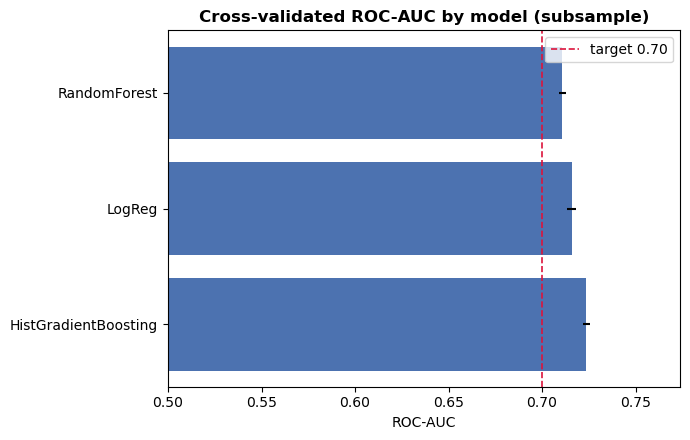

Leaderboard winner: HistGradientBoosting


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(board["model"], board["roc_auc"], xerr=board["roc_auc_std"], color="#4C72B0")
ax.set_xlim(0.5, max(0.75, board["roc_auc"].max() + 0.05))
ax.axvline(0.70, color="crimson", ls="--", lw=1.2, label="target 0.70")
ax.set_title("Cross-validated ROC-AUC by model (subsample)")
ax.set_xlabel("ROC-AUC"); ax.legend(); plt.tight_layout(); plt.show()

winner_name = board.iloc[0]["model"]
print("Leaderboard winner:", winner_name)

## 3 · Hyperparameter tuning

Randomized search over the winning family on a subsample, scored on ROC-AUC. The
search space uses the `clf__` prefix to reach the estimator inside the pipeline.
The best configuration is refit on the **full** training set in §4.

In [10]:
def search_space(name):
    if name == "RandomForest":
        return {"clf__n_estimators": [200, 400, 600],
                "clf__max_depth": [None, 12, 20, 30],
                "clf__min_samples_leaf": [1, 5, 20, 50],
                "clf__max_features": ["sqrt", "log2", 0.3]}
    if name in ("LightGBM", "XGBoost"):
        return {"clf__n_estimators": [300, 500, 800],
                "clf__learning_rate": [0.02, 0.05, 0.1],
                "clf__num_leaves": [31, 63, 127] if name == "LightGBM" else [0],
                "clf__max_depth": [-1, 6, 10] if name == "LightGBM" else [4, 6, 8],
                "clf__subsample": [0.7, 0.8, 1.0],
                "clf__colsample_bytree": [0.7, 0.8, 1.0]}
    if name == "HistGradientBoosting":
        return {"clf__max_iter": [300, 500, 800],
                "clf__learning_rate": [0.02, 0.05, 0.1],
                "clf__max_depth": [None, 6, 10],
                "clf__l2_regularization": [0.0, 1.0, 10.0]}
    return {"clf__C": np.logspace(-2, 2, 20)}   # LogReg

# Tuning subsample.
tidx = (X_train.assign(_y=y_train.values).groupby("_y", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), TUNE_SAMPLE_N // 2),
                                  random_state=RANDOM_STATE)).index)
Xt, yt = X_train.loc[tidx], y_train.loc[tidx]

if winner_name in ("LightGBM", "XGBoost", "HistGradientBoosting"):
    base_clf = make_gbm(yt)[0]
elif winner_name == "RandomForest":
    base_clf = RandomForestClassifier(class_weight="balanced_subsample",
                                      n_jobs=-1, random_state=RANDOM_STATE)
else:
    base_clf = LogisticRegression(max_iter=1000, class_weight="balanced",
                                  solver="saga", n_jobs=-1, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    make_pipeline(base_clf), search_space(winner_name),
    n_iter=N_SEARCH_ITER, scoring="roc_auc", cv=3, n_jobs=-1,
    random_state=RANDOM_STATE, refit=True, verbose=1)
search.fit(Xt, yt)
print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best CV ROC-AUC: 0.7237
Best params: {'clf__max_iter': 500, 'clf__max_depth': 6, 'clf__learning_rate': 0.05, 'clf__l2_regularization': 10.0}


## 4 · Fit the final model on the full training set

We rebuild the pipeline with the tuned estimator params and fit on all training
rows, then score both test sets.

In [11]:
best_clf_params = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}

if winner_name in ("LightGBM", "XGBoost", "HistGradientBoosting"):
    final_clf = make_gbm(y_train, **best_clf_params)[0]
elif winner_name == "RandomForest":
    final_clf = RandomForestClassifier(class_weight="balanced_subsample",
                                       n_jobs=-1, random_state=RANDOM_STATE, **best_clf_params)
else:
    final_clf = LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga",
                                   n_jobs=-1, random_state=RANDOM_STATE, **best_clf_params)

final_model = make_pipeline(final_clf)
t0 = time.time(); final_model.fit(X_train, y_train)
print(f"Fitted {winner_name} on {len(X_train):,} rows in {time.time()-t0:.0f}s")

proba_test = final_model.predict_proba(X_test)[:, 1]
print(f"Stratified TEST — ROC-AUC {roc_auc_score(y_test, proba_test):.4f} | "
      f"PR-AUC {average_precision_score(y_test, proba_test):.4f}")

target_met = roc_auc_score(y_test, proba_test) >= 0.70
print("Numeric success target (ROC-AUC >= 0.70):", "MET" if target_met else "NOT MET")

Fitted HistGradientBoosting on 1,078,479 rows in 105s
Stratified TEST — ROC-AUC 0.7310 | PR-AUC 0.4081
Numeric success target (ROC-AUC >= 0.70): MET


## 5 · The central experiment — with vs. without LendingClub's grades

`grade`/`sub_grade`/`int_rate` are LendingClub's own risk outputs. The **primary
model excludes them** (an independent model that could audit rather than echo the
client's scoring). Here we retrain the same tuned family **including** them and
report the ROC-AUC / PR-AUC lift — quantifying how much incremental signal the
client's grade actually adds.

In [12]:
def build_variant(include_lc_risk):
    Xv = df.drop(columns=[c for c in ["target", "issue_dt"] if c in df.columns])
    if not include_lc_risk:
        Xv = Xv.drop(columns=[c for c in LC_RISK_COLS if c in Xv.columns])
    Xtr_v, Xte_v, ytr_v, yte_v = train_test_split(
        Xv, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    clf = make_gbm(ytr_v, **best_clf_params)[0] if winner_name in (
        "LightGBM","XGBoost","HistGradientBoosting") else clone(final_clf)
    m = make_pipeline(clf).fit(Xtr_v, ytr_v)
    p = m.predict_proba(Xte_v)[:, 1]
    return roc_auc_score(yte_v, p), average_precision_score(yte_v, p)

auc_wo, ap_wo = roc_auc_score(y_test, proba_test), average_precision_score(y_test, proba_test)
auc_w,  ap_w  = build_variant(include_lc_risk=True)
print(f"WITHOUT LC grades (primary): ROC-AUC {auc_wo:.4f} | PR-AUC {ap_wo:.4f}")
print(f"WITH LC grades (benchmark) : ROC-AUC {auc_w:.4f} | PR-AUC {ap_w:.4f}")
print(f"Incremental ROC-AUC from LC's own grades: {auc_w - auc_wo:+.4f}")

WITHOUT LC grades (primary): ROC-AUC 0.7310 | PR-AUC 0.4081
WITH LC grades (benchmark) : ROC-AUC 0.7350 | PR-AUC 0.4122
Incremental ROC-AUC from LC's own grades: +0.0040


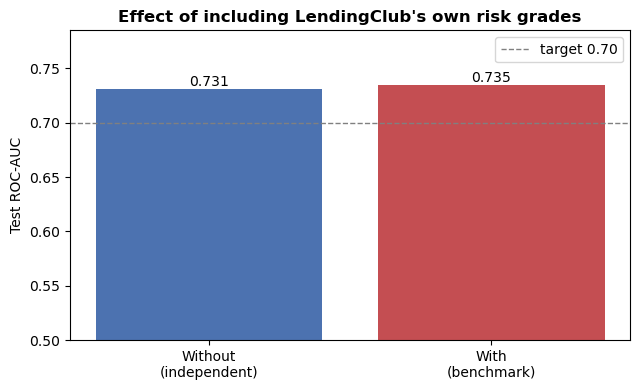

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["Without\n(independent)", "With\n(benchmark)"], [auc_wo, auc_w],
       color=["#4C72B0", "#C44E52"])
for i, v in enumerate([auc_wo, auc_w]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
ax.axhline(0.70, color="gray", ls="--", lw=1, label="target 0.70")
ax.set_ylim(0.5, max(auc_w, auc_wo) + 0.05)
ax.set_title("Effect of including LendingClub's own risk grades")
ax.set_ylabel("Test ROC-AUC"); ax.legend(); plt.tight_layout(); plt.show()

> **Optional leakage demonstration.** If the raw accepted file is on disk, you
> can train a quick model that *includes* a couple of post-funding fields (e.g.
> `total_pymnt`, `recoveries`) and watch ROC-AUC leap toward ~0.99 — the concrete
> proof that the Notebook 01 whitelist is doing real work. Left as an optional,
> clearly-labelled experiment rather than part of the deliverable.

## 6 · Test-set evaluation — curves, confusion, drift

ROC and PR curves on the stratified holdout, a confusion matrix at the default
0.5 cutoff (retuned in §7), and the later-vintage test to expose drift. Read the
time-based number with the Notebook 01 §2.1 survivorship caveat in mind.

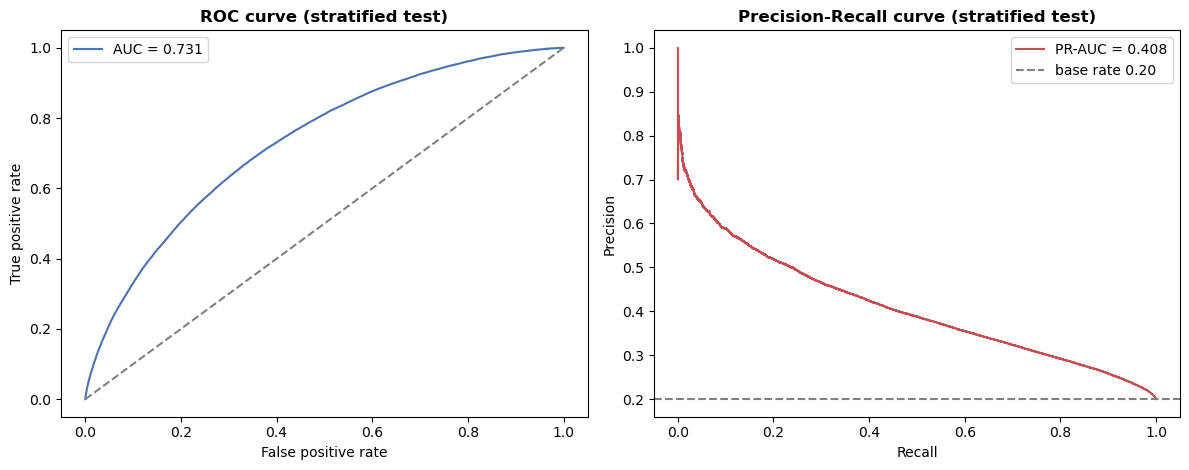

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, color="#4C72B0", label=f"AUC = {auc_wo:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC curve (stratified test)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, color="#C44E52", label=f"PR-AUC = {ap_wo:.3f}")
axes[1].axhline(y_test.mean(), ls="--", color="gray", label=f"base rate {y_test.mean():.2f}")
axes[1].set_title("Precision-Recall curve (stratified test)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()

In [15]:
# Later-vintage (time-based) generalization.
final_time = make_pipeline(
    make_gbm(ytr_t, **best_clf_params)[0] if winner_name in
    ("LightGBM","XGBoost","HistGradientBoosting") else clone(final_clf)).fit(Xtr_t, ytr_t)
p_time = final_time.predict_proba(Xte_t)[:, 1]
print(f"Time-based TEST (2017-18) — ROC-AUC {roc_auc_score(yte_t, p_time):.4f} | "
      f"PR-AUC {average_precision_score(yte_t, p_time):.4f}")
print(f"Drop vs stratified: {roc_auc_score(yte_t, p_time) - auc_wo:+.4f} "
      "(some drop expected under drift + vintage censoring)")

Time-based TEST (2017-18) — ROC-AUC 0.7232 | PR-AUC 0.4069
Drop vs stratified: -0.0078 (some drop expected under drift + vintage censoring)


## 7 · Threshold tuning — cost-sensitive

The deployment decision is a **risk cutoff**, not a 0.5 rule. A missed default
(false negative) costs far more than a wrongly-declined good loan (false positive).
We sweep thresholds and pick the one minimizing expected cost, using average
per-loan costs derived from the business assumptions.

Avg principal $14,396 | cost FN $7,918 | cost FP $1,728
Cost-minimizing threshold: 0.46


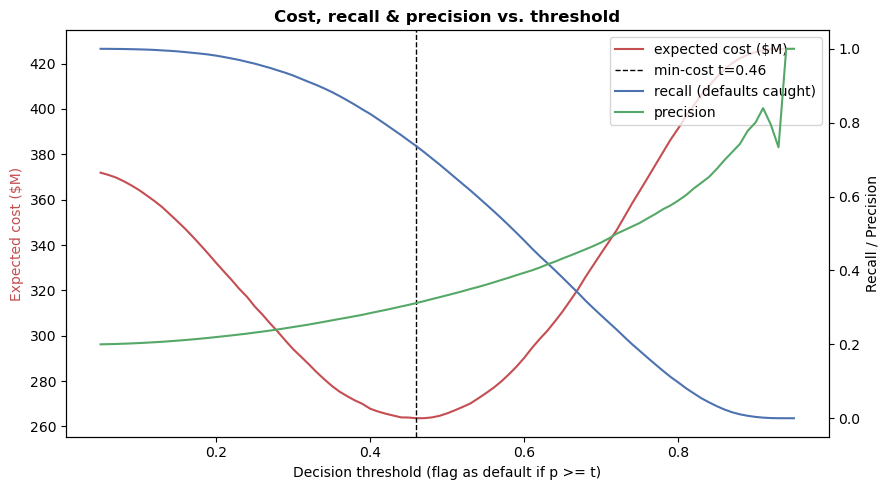

In [16]:
avg_principal = X_test["loan_amnt"].astype(float).mean()
COST_FN = avg_principal * LGD      # missing a defaulter -> lose LGD of principal
COST_FP = avg_principal * MARGIN   # declining a good loan -> forgo the margin
print(f"Avg principal ${avg_principal:,.0f} | cost FN ${COST_FN:,.0f} | cost FP ${COST_FP:,.0f}")

ths = np.linspace(0.05, 0.95, 91)
costs, recalls, precisions = [], [], []
for t in ths:
    pred = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)
    recalls.append(tp / (tp + fn)); precisions.append(tp / (tp + fp + 1e-9))

best_t = ths[int(np.argmin(costs))]
print(f"Cost-minimizing threshold: {best_t:.2f}")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(ths, np.array(costs)/1e6, color="#C44E52", label="expected cost ($M)")
ax1.axvline(best_t, color="black", ls="--", lw=1, label=f"min-cost t={best_t:.2f}")
ax1.set_xlabel("Decision threshold (flag as default if p >= t)")
ax1.set_ylabel("Expected cost ($M)", color="#C44E52")
ax2 = ax1.twinx()
ax2.plot(ths, recalls, color="#4C72B0", label="recall (defaults caught)")
ax2.plot(ths, precisions, color="#55A868", label="precision")
ax2.set_ylabel("Recall / Precision")
ax1.set_title("Cost, recall & precision vs. threshold")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
plt.tight_layout(); plt.show()

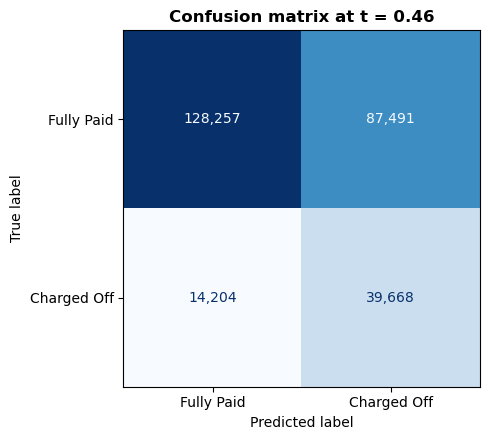

Recall 0.736 | Precision 0.312 | Defaults caught 39,668/53,872


In [17]:
pred_best = (proba_test >= best_t).astype(int)
cm = confusion_matrix(y_test, pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fully Paid", "Charged Off"])
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
ax.set_title(f"Confusion matrix at t = {best_t:.2f}")
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"Recall {tp/(tp+fn):.3f} | Precision {tp/(tp+fp):.3f} | "
      f"Defaults caught {tp:,}/{tp+fn:,}")

## 8 · Calibration

For the risk score and ROI to be trustworthy, predicted probabilities should match
observed default frequencies. We plot a reliability curve and report the Brier
score; if the model is miscalibrated, wrap it in `CalibratedClassifierCV` (isotonic).

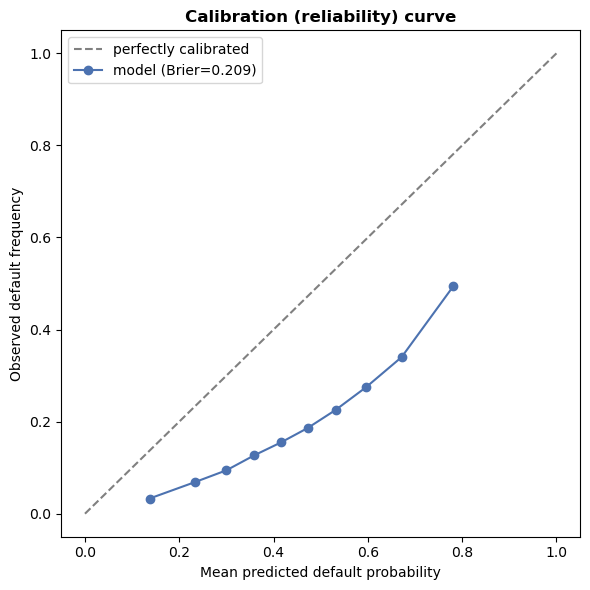

In [18]:
frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
ax.plot(mean_pred, frac_pos, marker="o", color="#4C72B0",
        label=f"model (Brier={brier:.3f})")
ax.set_title("Calibration (reliability) curve")
ax.set_xlabel("Mean predicted default probability")
ax.set_ylabel("Observed default frequency"); ax.legend()
plt.tight_layout(); plt.show()

## 9 · Business impact — lift/gains and the approval-rate dial

Two executive views:
1. **Lift / gains** — sort applicants by predicted risk; how many of the actual
   defaulters land in the riskiest slice.
2. **Approval-rate dial** — approve the safest X% and read off realized default
   rate, **dollar loss avoided**, and **profit** (repaid-loan margin − defaulted-loan
   loss). The threshold is a business choice mapped to the client's risk appetite.

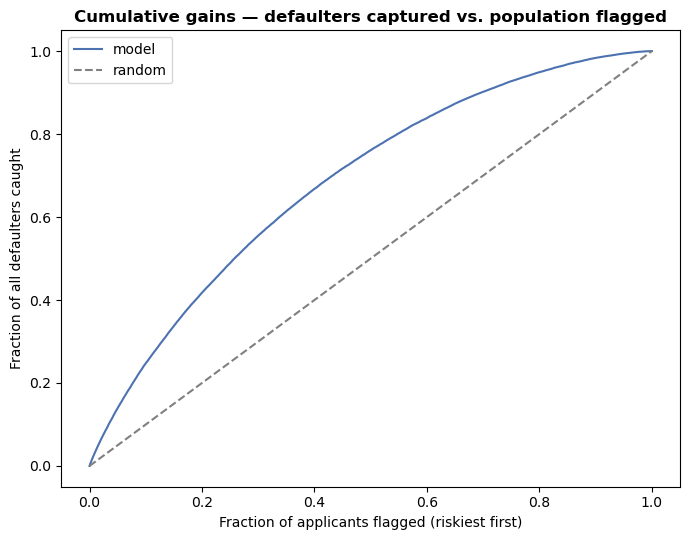

Top 10% riskiest capture 24.7% of defaulters (lift 2.47x)
Top 20% riskiest capture 41.8% of defaulters (lift 2.09x)
Top 30% riskiest capture 55.5% of defaulters (lift 1.85x)


In [19]:
# --- Lift / gains curve ------------------------------------------------------
order = np.argsort(-proba_test)                # riskiest first
y_sorted = y_test.values[order]
gains = np.cumsum(y_sorted) / y_sorted.sum()
frac_pop = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(frac_pop, gains, color="#4C72B0", label="model")
ax.plot([0, 1], [0, 1], "--", color="gray", label="random")
ax.set_title("Cumulative gains — defaulters captured vs. population flagged")
ax.set_xlabel("Fraction of applicants flagged (riskiest first)")
ax.set_ylabel("Fraction of all defaulters caught"); ax.legend()
plt.tight_layout(); plt.show()
for q in (0.1, 0.2, 0.3):
    k = int(q * len(y_sorted))
    print(f"Top {int(q*100)}% riskiest capture {gains[k-1]*100:.1f}% of defaulters "
          f"(lift {gains[k-1]/q:.2f}x)")

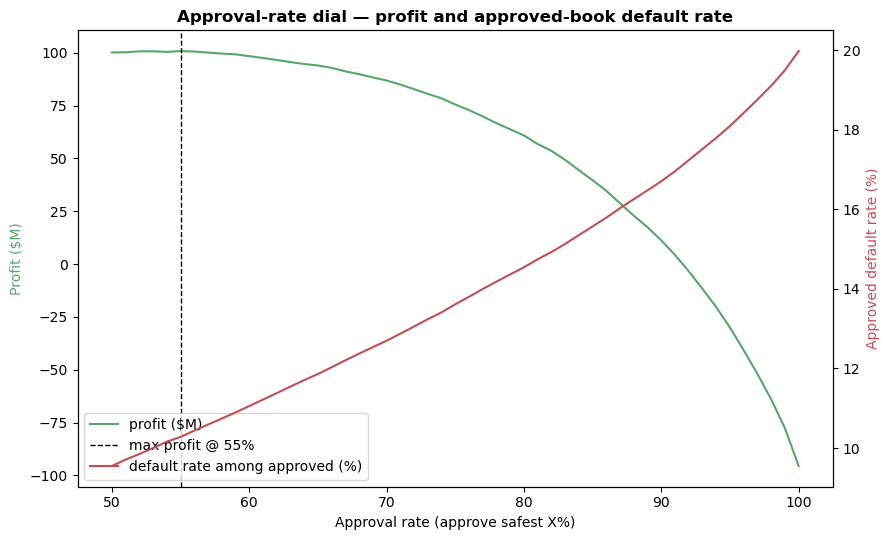

Profit-maximizing approval rate: 55% -> approved default rate 10.3%, profit $100.8M, loss avoided vs. approving all $351.8M (on the held-out test book)


In [20]:
# --- Approval-rate dial: loss avoided & profit -------------------------------
principal = X_test["loan_amnt"].astype(float).values
safe_order = np.argsort(proba_test)            # safest first (approve these)
y_ord = y_test.values[safe_order]; pr_ord = principal[safe_order]

rates = np.linspace(0.5, 1.0, 51)
rows = []
for a in rates:
    k = int(a * len(y_ord))
    appr_y, appr_pr = y_ord[:k], pr_ord[:k]
    loss = (appr_pr[appr_y == 1].sum()) * LGD
    revenue = (appr_pr[appr_y == 0].sum()) * MARGIN
    rows.append({"approval_rate": a,
                 "approved_default_rate": appr_y.mean() if k else np.nan,
                 "loss_$": loss, "profit_$": revenue - loss})
econ = pd.DataFrame(rows)

# Baseline: approve everyone (indiscriminate lending).
base_loss = (pr_ord[y_ord == 1].sum()) * LGD
econ["loss_avoided_vs_all_$"] = base_loss - econ["loss_$"]
best_profit_row = econ.loc[econ["profit_$"].idxmax()]

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.plot(econ["approval_rate"]*100, econ["profit_$"]/1e6, color="#55A868", label="profit ($M)")
ax1.axvline(best_profit_row["approval_rate"]*100, color="black", ls="--", lw=1,
            label=f"max profit @ {best_profit_row['approval_rate']*100:.0f}%")
ax1.set_xlabel("Approval rate (approve safest X%)"); ax1.set_ylabel("Profit ($M)", color="#55A868")
ax2 = ax1.twinx()
ax2.plot(econ["approval_rate"]*100, econ["approved_default_rate"]*100, color="#C44E52",
         label="default rate among approved (%)")
ax2.set_ylabel("Approved default rate (%)", color="#C44E52")
ax1.set_title("Approval-rate dial — profit and approved-book default rate")
lines = ax1.get_lines()[:2] + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")
plt.tight_layout(); plt.show()

print(f"Profit-maximizing approval rate: {best_profit_row['approval_rate']*100:.0f}% "
      f"-> approved default rate {best_profit_row['approved_default_rate']*100:.1f}%, "
      f"profit ${best_profit_row['profit_$']/1e6:.1f}M, "
      f"loss avoided vs. approving all ${best_profit_row['loss_avoided_vs_all_$']/1e6:.1f}M "
      "(on the held-out test book)")

## 10 · Interpretability — what drives the score

SHAP if available (tree models), otherwise permutation importance. These are the
drivers the risk team will want to see, and the fair-lending guardrail will review.

SHAP unavailable/failed, using permutation importance: No module named 'shap'


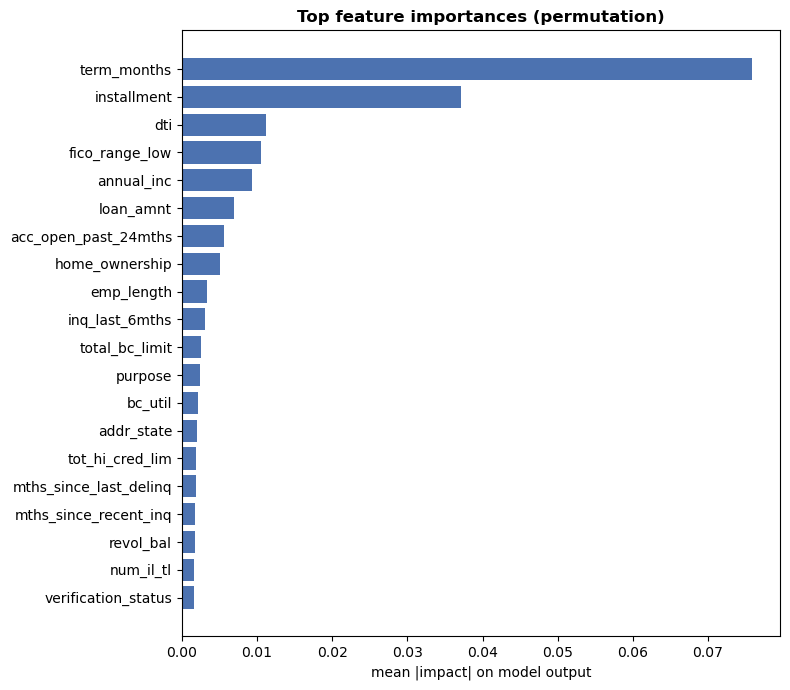

term_months             0.075795
installment             0.037198
dti                     0.011249
fico_range_low          0.010541
annual_inc              0.009277
loan_amnt               0.006914
acc_open_past_24mths    0.005563
home_ownership          0.005047
emp_length              0.003390
inq_last_6mths          0.003073
total_bc_limit          0.002575
purpose                 0.002390
dtype: float64


In [21]:
feat_names = final_model.named_steps["prep"].get_feature_names_out()

def clean(names):
    return [n.replace("num__", "").replace("cat__", "") for n in names]

used_shap = False
try:
    import shap
    tree_like = winner_name in ("LightGBM", "XGBoost", "RandomForest", "HistGradientBoosting")
    if tree_like:
        samp = X_test.sample(min(3000, len(X_test)), random_state=RANDOM_STATE)
        Xt_s = final_model.named_steps["prep"].transform(
            final_model.named_steps["fe"].transform(samp))
        Xt_s = Xt_s.toarray() if hasattr(Xt_s, "toarray") else Xt_s
        explainer = shap.TreeExplainer(final_model.named_steps["clf"])
        sv = explainer.shap_values(Xt_s)
        sv = sv[1] if isinstance(sv, list) else sv
        imp = pd.Series(np.abs(sv).mean(0), index=clean(feat_names)).sort_values(ascending=False)
        used_shap = True
except Exception as e:
    print("SHAP unavailable/failed, using permutation importance:", e)

if not used_shap:
    from sklearn.inspection import permutation_importance
    samp = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
    ys_ = y_test.loc[samp.index]
    pi = permutation_importance(final_model, samp, ys_, n_repeats=5,
                                scoring="roc_auc", random_state=RANDOM_STATE, n_jobs=-1)
    # Permutation importance is over raw input columns.
    imp = pd.Series(pi.importances_mean, index=samp.columns).sort_values(ascending=False)

top = imp.head(20)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index[::-1], top.values[::-1], color="#4C72B0")
ax.set_title(f"Top feature importances ({'SHAP' if used_shap else 'permutation'})")
ax.set_xlabel("mean |impact| on model output")
plt.tight_layout(); plt.show()
print(top.head(12))

## 11 · Serialize the final model + model card

In [22]:
model_path = os.path.join(MODEL_DIR, "final_default_model.joblib")
joblib.dump(final_model, model_path)

card = {
    "model_family": winner_name,
    "best_params": best_clf_params,
    "include_lc_risk": INCLUDE_LC_RISK,
    "test_roc_auc": float(auc_wo), "test_pr_auc": float(ap_wo),
    "time_test_roc_auc": float(roc_auc_score(yte_t, p_time)),
    "roc_auc_with_lc_grades": float(auc_w),
    "operating_threshold": float(best_t),
    "profit_max_approval_rate": float(best_profit_row["approval_rate"]),
    "business_assumptions": {"LGD": LGD, "MARGIN": MARGIN},
    "n_train": int(len(X_train)), "n_features_in": int(X.shape[1]),
    "sklearn_version": sklearn.__version__,
}
with open(os.path.join(MODEL_DIR, "model_card.json"), "w") as f:
    json.dump(card, f, indent=2)
print("Saved:", model_path)
print(json.dumps(card, indent=2))

# Reload check (fresh-process-safe because classes live in src/lc_transformers.py).
reloaded = joblib.load(model_path)
assert np.allclose(reloaded.predict_proba(X_test.head(500))[:, 1], proba_test[:500])
print("Reload check passed.")

Saved: models\final_default_model.joblib
{
  "model_family": "HistGradientBoosting",
  "best_params": {
    "max_iter": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "l2_regularization": 10.0
  },
  "include_lc_risk": false,
  "test_roc_auc": 0.7309802203767037,
  "test_pr_auc": 0.4081406287582911,
  "time_test_roc_auc": 0.7232137246452142,
  "roc_auc_with_lc_grades": 0.7349691466864627,
  "operating_threshold": 0.4599999999999999,
  "profit_max_approval_rate": 0.55,
  "business_assumptions": {
    "LGD": 0.55,
    "MARGIN": 0.12
  },
  "n_train": 1078479,
  "n_features_in": 85,
  "sklearn_version": "1.6.1"
}
Reload check passed.


## 12 · Secondary — policy-characterization model (approved vs. declined)

A **descriptive** model of the client's *historical* approval behavior on the
harmonized shared columns. It is **not** a predictor of future approvals and makes
**no** counterfactual claim about whether declined applicants would have defaulted
(the rejected file has no outcome). We fit it **with and without** the
`Risk_Score_missing` flag to test whether the *absence* of a score was itself
informative, and read approval propensity by geography for the fairness lens.

In [23]:
# Accepted side (approved=1) from the interim parquet.
acc_side = pd.DataFrame({
    "amount": df["loan_amnt"].astype(float),
    "credit": df.get("fico_mid"),
    "dti": df["dti"].astype(float) if "dti" in df.columns else np.nan,
    "state": df.get("addr_state"),
    "approved": 1,
})

# Rejected side (approved=0): sampled chunked read of the raw file.
POLICY_REJECTED_N = 300_000
if os.path.exists(REJECTED_CSV):
    usecols = ["Amount Requested", "Risk_Score", "Debt-To-Income Ratio", "State"]
    keep_p = min(1.0, POLICY_REJECTED_N / 27_648_741)
    rng = np.random.default_rng(RANDOM_STATE); parts = []
    for ch in pd.read_csv(REJECTED_CSV, usecols=usecols, chunksize=1_000_000, low_memory=False):
        parts.append(ch.loc[rng.random(len(ch)) < keep_p])
    rej = pd.concat(parts, ignore_index=True)
    rej_side = pd.DataFrame({
        "amount": pd.to_numeric(rej["Amount Requested"], errors="coerce"),
        "credit": pd.to_numeric(rej["Risk_Score"], errors="coerce"),
        "dti": (rej["Debt-To-Income Ratio"].astype(str).str.replace("%", "", regex=False)
                .str.strip().replace({"nan": np.nan, "": np.nan}).astype(float)),
        "state": rej["State"], "approved": 0,
    })
    funnel = pd.concat([acc_side, rej_side], ignore_index=True)
    print("Funnel built:", funnel["approved"].value_counts().to_dict())
else:
    funnel = None
    print("Rejected file not found — skipping policy model. Set REJECTED_CSV.")

Rejected file not found — skipping policy model. Set REJECTED_CSV.


In [24]:
if funnel is not None:
    from sklearn.metrics import roc_auc_score as _auc

    # Balance the classes for a tractable, comparable fit.
    n_per = min(funnel["approved"].value_counts().min(), 200_000)
    bal = (funnel.groupby("approved", group_keys=False)
                 .sample(n=n_per, random_state=RANDOM_STATE)
                 .reset_index(drop=True))
    Xp = bal.drop(columns=["approved"]); yp = bal["approved"].astype(int)
    Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
        Xp, yp, test_size=0.25, stratify=yp, random_state=RANDOM_STATE)

    def policy_pipe(add_flag):
        prep = ColumnTransformer(
            [("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                               ("scale", StandardScaler())]),
              make_column_selector(dtype_include=np.number)),
             ("cat", Pipeline([("rare", RareCategoryGrouper(top_n=15)),
                               ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                               ("ohe", OneHotEncoder(handle_unknown="ignore"))]),
              make_column_selector(dtype_include=["object", "category"]))],
            remainder="drop")
        return Pipeline([("flag", RiskMissingFlag(add_flag=add_flag, credit_col="credit")),
                         ("prep", prep),
                         ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                    solver="saga", n_jobs=-1,
                                                    random_state=RANDOM_STATE))])

    for add_flag in (False, True):
        m = policy_pipe(add_flag).fit(Xp_tr, yp_tr)
        p = m.predict_proba(Xp_te)[:, 1]
        tag = "with" if add_flag else "without"
        print(f"Policy model {tag} Risk_Score_missing flag -> ROC-AUC {_auc(yp_te, p):.4f}")
        if add_flag:
            policy_model = m

In [25]:
if funnel is not None:
    # Approval drivers: standardized logistic-regression coefficients.
    names = clean(policy_model.named_steps["prep"].get_feature_names_out())
    coefs = pd.Series(policy_model.named_steps["clf"].coef_[0], index=names)
    top_drivers = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
    print("Top historical-approval drivers (+ = toward approval):")
    print(top_drivers.round(3))

    # Geographic approval propensity (sampled, directional).
    geo = (funnel.dropna(subset=["state"]).groupby("state")["approved"]
                 .agg(["mean", "size"]))
    geo = geo[geo["size"] >= 300].sort_values("mean")
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(geo.index, geo["mean"]*100, color="#4C72B0")
    ax.set_title("Approved share by state (sampled) — geographic fairness signal")
    ax.set_xlabel("State"); ax.set_ylabel("% approved in sample")
    plt.setp(ax.get_xticklabels(), rotation=90); plt.tight_layout(); plt.show()

> **Fairness scope.** The data contain **no race, gender, age, or other
> protected-class fields**, so this analysis is limited to **geography** (state)
> and is a **directional** signal for further compliance review — not a legal
> determination of disparate impact.

## 13 · Summary & limitations

**Results**
- Three algorithms compared in the leak-free pipeline; the winner was tuned and
  refit on the full training set. Primary (independent) test **ROC-AUC** reported
  against the **≥ 0.70 target**; the **with-grades benchmark** quantifies the
  incremental signal from LendingClub's own scoring.
- Evaluated on a stratified holdout **and** a later-vintage test; threshold tuned
  on business cost; calibration checked; scores translated into **lift/gains** and
  an **approval-rate profit / loss-avoided** story.
- Secondary policy model describes historical approval drivers with/without the
  `Risk_Score_missing` flag and a geographic fairness read.

**Limitations (documented, not hidden)**
- **Vintage survivorship** from the terminal-loan filter biases recent vintages
  (Notebook 01 §2.1) and colours the time-based test.
- **No reject inference / no counterfactual** for declined applicants — the policy
  model is descriptive only.
- **Fairness limited to geography** (no protected-class fields).
- Business ROI depends on the explicit **LGD / MARGIN** assumptions — swap in the
  client's real economics before quoting dollars.
- The credit-score comparison in the funnel mixes FICO and LC `Risk_Score`
  (different scales) — treated as directional.

**Deliverables produced:** `models/final_default_model.joblib`, `models/model_card.json`.